In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("ahmedelsany/car-brand-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 177M/177M [00:01<00:00, 148MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1):
['Car Brand Classification Dataset']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'test'))}")

Contents of the 'train' directory: ['BMW', 'Ford', 'INFINITI', 'Lincoln', 'Kia', 'FIAT', 'Jaguar', 'Volvo', 'Mercedes-Benz', 'Jeep', 'Chevrolet', 'Buick', 'Toyota', 'MINI', 'Honda', 'Nissan', 'Aston Martin', 'Land Rover', 'Porsche', 'Hyundai', 'Mitsubishi', 'Lexus', 'Subaru', 'Acura', 'Dodge', 'Mazda', 'Chrysler', 'Cadillac', 'GMC', 'Audi', 'Volkswagen', 'Ram', 'Bentley']
Contents of the 'test' directory: ['BMW', 'Ford', 'INFINITI', 'Lincoln', 'Kia', 'FIAT', 'Jaguar', 'Volvo', 'Mercedes-Benz', 'Jeep', 'Chevrolet', 'Buick', 'Toyota', 'MINI', 'Honda', 'Nissan', 'Aston Martin', 'Land Rover', 'Porsche', 'Hyundai', 'Mitsubishi', 'Lexus', 'Subaru', 'Acura', 'Dodge', 'Mazda', 'Chrysler', 'Cadillac', 'GMC', 'Audi', 'Volkswagen', 'Ram', 'Bentley']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/train) ---
Found 11517 images in /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/train. Displaying 6 samples:


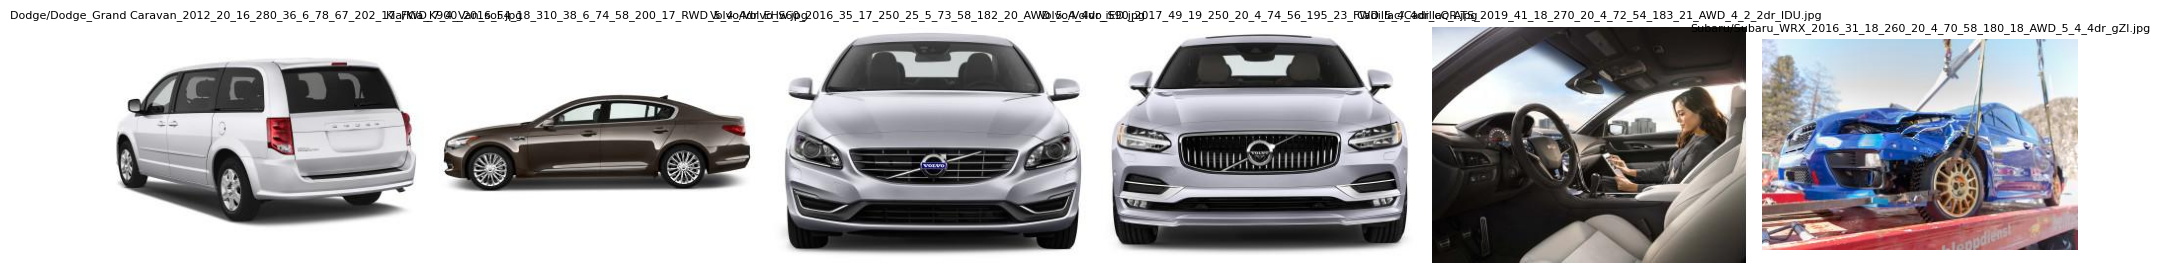


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/test) ---
Found 2475 images in /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/test. Displaying 6 samples:


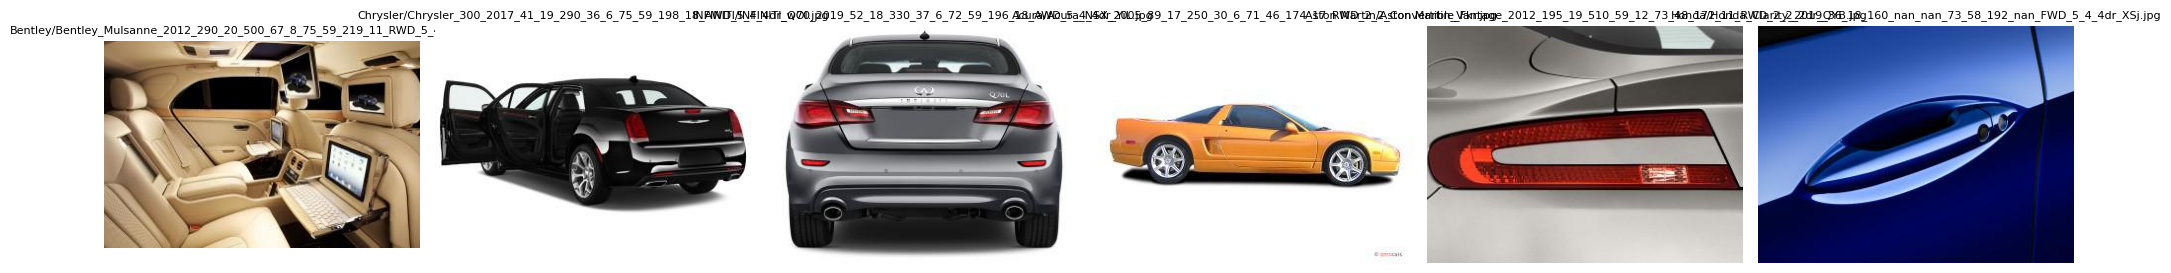

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Car Brand Classification Dataset' subdirectory
train_path = os.path.join(path, 'Car Brand Classification Dataset', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Car Brand Classification Dataset', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable GPU in Colab settings (Runtime > Change runtime type).')
else:
  print(f'Found GPU at: {device_name}')

# Verify physical devices
print("Physical Devices:", tf.config.list_physical_devices('GPU'))

Found GPU at: /device:GPU:0
Physical Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Configuration
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = len(os.listdir(train_path))

# Data Augmentation and Loading
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build InceptionV3 Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base model layers initially
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Training
print("Starting training...")
with tf.device('/device:GPU:0'):
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // BATCH_SIZE,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // BATCH_SIZE,
        epochs=EPOCHS
    )

Found 11517 images belonging to 33 classes.
Found 2475 images belonging to 33 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Starting training...
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 312s 812ms/step - accuracy: 0.0725 - loss: 3.3998 - val_accuracy: 0.1384 - val_loss: 3.1874
Epoch 2/10
  1/359 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.0625 - loss: 3.4139

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.0625 - loss: 3.4139 - val_accuracy: 0.1396 - val_loss: 3.1857
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 267s 742ms/step - accuracy: 0.0980 - loss: 3.2290 - val_accuracy: 0.1489 - val_loss: 3.1096
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.1562 - loss: 3.0914 - val_accuracy: 0.1445 - val_loss: 3.1065
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 267s 744ms/step - accuracy: 0.1128 - loss: 3.1637 - val_accuracy: 0.1696 - val_loss: 3.0048
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.2188 - loss: 3.1857 - val_accuracy: 0.1717 - val_loss: 3.0049
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 268s 746ms/step - accuracy: 0.1302 - loss: 3.1033 - val_accuracy: 0.1798 - val_loss: 2.9622
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.0938 - loss: 2.9953 - val_accuracy: 0.1778 - val_loss: 2.9579
Epoch 9/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 269s 749ms/step - accuracy: 0.1495 - loss: 3.0567 - val_acc

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Summary of class indices
class_indices = train_generator.class_indices
print("Class Mapping:", class_indices)

78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step - accuracy: 0.1960 - loss: 2.9491
Validation Loss: 2.9491
Validation Accuracy: 0.1960
Class Mapping: {'Acura': 0, 'Aston Martin': 1, 'Audi': 2, 'BMW': 3, 'Bentley': 4, 'Buick': 5, 'Cadillac': 6, 'Chevrolet': 7, 'Chrysler': 8, 'Dodge': 9, 'FIAT': 10, 'Ford': 11, 'GMC': 12, 'Honda': 13, 'Hyundai': 14, 'INFINITI': 15, 'Jaguar': 16, 'Jeep': 17, 'Kia': 18, 'Land Rover': 19, 'Lexus': 20, 'Lincoln': 21, 'MINI': 22, 'Mazda': 23, 'Mercedes-Benz': 24, 'Mitsubishi': 25, 'Nissan': 26, 'Porsche': 27, 'Ram': 28, 'Subaru': 29, 'Toyota': 30, 'Volkswagen': 31, 'Volvo': 32}


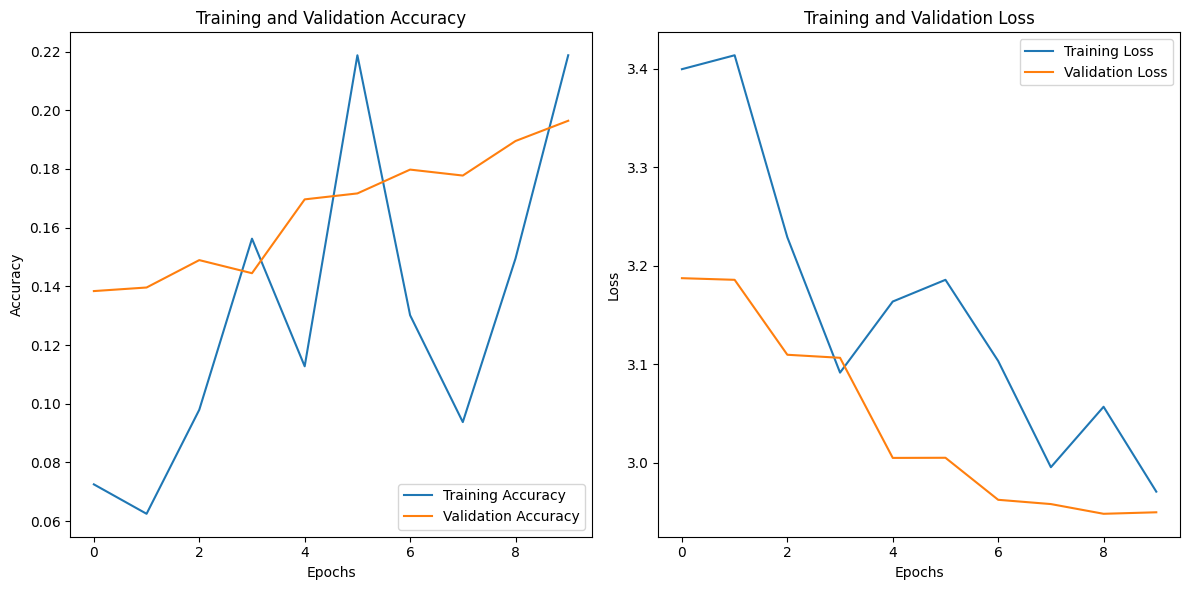

In [ ]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()